# Experiment 4.3 — Stage-2 long-term-memory and recurrence validation

Analysis-only notebook for the finalized artifacts produced by `scripts/experiment_4_3_long_term_memory_validation.py`. It does **not** train or re-evaluate models.

The notebook mirrors the four validation questions:

1. **V1 — FF vs RSNN:** does recurrence improve the current Stage-2 decoder?
2. **V2 — recurrence-off:** does the trained RSNN actually depend on recurrent feedback at inference?
3. **V3 — periodic Stage-2 reset:** how much does limiting the Stage-2 memory horizon hurt?
4. **V4 — silent-delay retention:** how long does endpoint information remain decodable after the input stops?

Primary memory diagnostic: **Stage-2 endpoint membrane (`Uend`) + the frozen train-only Linear probe**. Output WholeCount is shown as a secondary system metric because it is itself an evidence accumulator.

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

EXPERIMENT_ID = 'experiment_4_3_long_term_memory_validation'
PROTOCOL_VERSION = 'stage2_recurrence_memory_validation_v1'
EXPECTED_SEEDS = (11, 23, 37, 53, 71)
EXPECTED_DELAYS_MS = (0, 250, 500, 1000, 2000)
EXPECTED_RESET_MS = (250, 500, 1000)

def find_repo_root(start: Path = Path.cwd()) -> Path:
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / 'pyproject.toml').exists() and (candidate / 'scripts').exists():
            return candidate
    raise FileNotFoundError('Could not locate writingRing repository root')

REPO_ROOT = find_repo_root()
ARTIFACT_DIR = REPO_ROOT / 'notebooks' / 'artifacts' / EXPERIMENT_ID / PROTOCOL_VERSION
REQUIRED_FILES = {
    'classification_runs': 'classification_runs.csv',
    'classification_summary': 'classification_summary.csv',
    'retention_runs': 'retention_runs.csv',
    'retention_summary': 'retention_summary.csv',
    'paired_effects': 'paired_effects.csv',
    'paired_effects_summary': 'paired_effects_summary.csv',
    'manifest': 'manifest.json',
}
missing = [name for name in REQUIRED_FILES.values() if not (ARTIFACT_DIR / name).exists()]
if missing:
    raise FileNotFoundError(
        f'Missing finalized Exp4.3 artifacts under {ARTIFACT_DIR}: {missing}. '
        'Run the Slurm arrays and finalizer first.'
    )

manifest = json.loads((ARTIFACT_DIR / REQUIRED_FILES['manifest']).read_text(encoding='utf-8'))
classification_runs = pd.read_csv(ARTIFACT_DIR / REQUIRED_FILES['classification_runs'])
classification_summary = pd.read_csv(ARTIFACT_DIR / REQUIRED_FILES['classification_summary'])
retention_runs = pd.read_csv(ARTIFACT_DIR / REQUIRED_FILES['retention_runs'])
retention_summary = pd.read_csv(ARTIFACT_DIR / REQUIRED_FILES['retention_summary'])
paired_effects = pd.read_csv(ARTIFACT_DIR / REQUIRED_FILES['paired_effects'])
paired_effects_summary = pd.read_csv(ARTIFACT_DIR / REQUIRED_FILES['paired_effects_summary'])

assert manifest['experiment_id'] == EXPERIMENT_ID
assert manifest['protocol_version'] == PROTOCOL_VERSION
assert tuple(manifest['seeds']) == EXPECTED_SEEDS
assert set(classification_runs['model_kind']) == {'ff', 'rsnn'}
assert set(retention_runs['model_kind']) == {'ff', 'rsnn'}
assert set(classification_runs['seed'].unique()) == set(EXPECTED_SEEDS)
assert set(retention_runs['seed'].unique()) == set(EXPECTED_SEEDS)
assert set(retention_runs['delay_ms'].unique()) == set(EXPECTED_DELAYS_MS)

expected_ff_conditions = {'normal', 'reset_250ms', 'reset_500ms', 'reset_1000ms'}
expected_rsnn_conditions = expected_ff_conditions | {'recurrent_off'}
assert set(classification_runs.loc[classification_runs.model_kind == 'ff', 'condition']) == expected_ff_conditions
assert set(classification_runs.loc[classification_runs.model_kind == 'rsnn', 'condition']) == expected_rsnn_conditions

print(f'Artifact directory: {ARTIFACT_DIR}')
print(f'Loaded {len(classification_runs)} classification rows and {len(retention_runs)} retention rows.')


Artifact directory: /home/zhaolongwei_umass_edu/projects/writingRing/notebooks/artifacts/experiment_4_3_long_term_memory_validation/stage2_recurrence_memory_validation_v1
Loaded 135 classification rows and 150 retention rows.


## Finalizer outputs and protocol sanity check

These tables are the exact test-set aggregates produced by the Exp4.3 finalizer. Counts should be five for every seed-aggregated condition.

In [2]:
architecture = pd.DataFrame([manifest['fixed_architecture']])
display(architecture)
display(classification_summary.sort_values(['model_kind', 'condition']).reset_index(drop=True))
display(retention_summary.sort_values(['model_kind', 'delay_ms']).reset_index(drop=True))

assert (classification_summary.filter(regex='_count$') == len(EXPECTED_SEEDS)).all().all()
assert (retention_summary.filter(regex='_count$') == len(EXPECTED_SEEDS)).all().all()


,hidden_cap,local_condition,output_cap,stage2_tau_mem_ms,stage2_width,variant
0,31,shift34,31,250.0,128,multi_ho


,model_kind,condition,output_whole_count_ba_mean,output_whole_count_ba_std,output_whole_count_ba_count,hidden_whole_count_linear_ba_mean,hidden_whole_count_linear_ba_std,hidden_whole_count_linear_ba_count,uend_linear_ba_mean,uend_linear_ba_std,uend_linear_ba_count
0,ff,normal,0.472060,0.027412,5,0.516052,0.022842,5,0.178183,0.029920,5
1,ff,reset_1000ms,0.471371,0.034138,5,0.499404,0.038384,5,0.172558,0.010649,5
2,ff,reset_250ms,0.456305,0.013954,5,0.496266,0.032675,5,0.124122,0.027208,5
3,ff,reset_500ms,0.471986,0.023047,5,0.505908,0.022219,5,0.150459,0.015144,5
4,rsnn,normal,0.497990,0.047480,5,0.501776,0.023751,5,0.542980,0.014059,5
5,rsnn,recurrent_off,0.095221,0.033435,5,0.096520,0.015877,5,0.082424,0.021575,5
6,rsnn,reset_1000ms,0.283790,0.043417,5,0.282796,0.037292,5,0.225625,0.025647,5
7,rsnn,reset_250ms,0.137881,0.030495,5,0.154986,0.024633,5,0.103582,0.009681,5
8,rsnn,reset_500ms,0.170447,0.019949,5,0.182739,0.026719,5,0.167665,0.032294,5


,model_kind,delay_ms,uend_linear_ba_mean,uend_linear_ba_std,uend_linear_ba_count,uend_linear_macro_f1_mean,uend_linear_macro_f1_std,uend_linear_macro_f1_count
0,ff,0,0.178183,0.029920,5,0.178012,0.032246,5
1,ff,250,0.123449,0.029492,5,0.076026,0.025584,5
2,ff,500,0.098147,0.023265,5,0.026614,0.019067,5
3,ff,1000,0.083333,0.000000,5,0.012281,0.002187,5
4,ff,2000,0.083333,0.000000,5,0.012244,0.002136,5
5,rsnn,0,0.542980,0.014059,5,0.535623,0.013930,5
6,rsnn,250,0.391490,0.098703,5,0.382649,0.096190,5
7,rsnn,500,0.241415,0.111141,5,0.196742,0.108731,5
8,rsnn,1000,0.102536,0.023722,5,0.044445,0.028457,5
9,rsnn,2000,0.083333,0.000000,5,0.013060,0.002171,5


## V1 — Independently trained FF vs frozen current RSNN

This comparison asks whether recurrent Stage-2 dynamics improve the same Local128 → Stage2-128 → output task beyond passive membrane persistence. The paired effect is `RSNN - FF`; positive values favor recurrence.

,model_kind,readout,mean,std,count
0,ff,Hidden WholeCount + Linear,0.516052,0.022842,5
1,ff,Output WholeCount,0.472060,0.027412,5
2,ff,Uend + Linear,0.178183,0.029920,5
3,rsnn,Hidden WholeCount + Linear,0.501776,0.023751,5
4,rsnn,Output WholeCount,0.497990,0.047480,5
5,rsnn,Uend + Linear,0.542980,0.014059,5


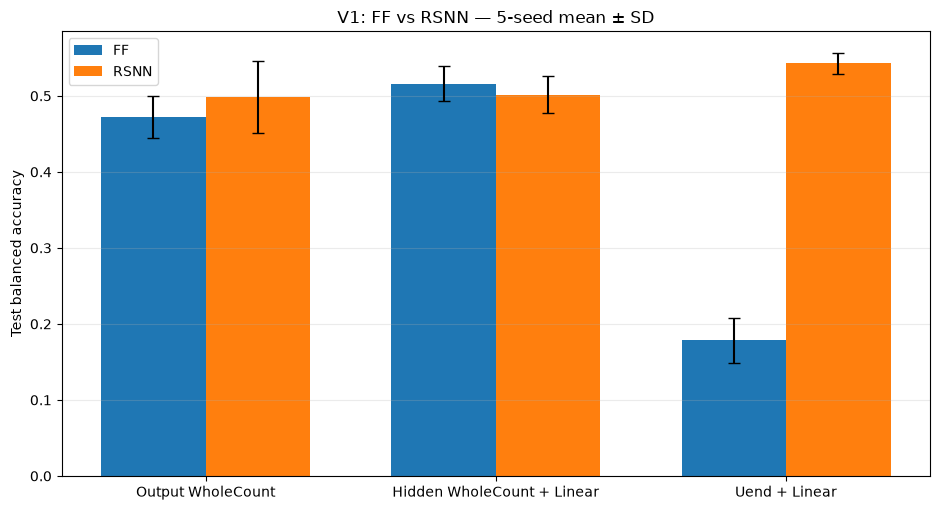

,readout,mean,std,count
0,hidden_whole_count_linear,-0.014277,0.039623,5
1,output_whole_count,0.025930,0.070680,5
2,uend_linear,0.364796,0.028036,5


In [3]:
READOUTS = {
    'output_whole_count_ba': 'Output WholeCount',
    'hidden_whole_count_linear_ba': 'Hidden WholeCount + Linear',
    'uend_linear_ba': 'Uend + Linear',
}
normal_test = classification_runs.query("split == 'test' and condition == 'normal'").copy()
v1_long = normal_test.melt(
    id_vars=['model_kind', 'seed'],
    value_vars=list(READOUTS),
    var_name='metric',
    value_name='balanced_accuracy',
)
v1_long['readout'] = v1_long['metric'].map(READOUTS)
v1_summary = (
    v1_long.groupby(['model_kind', 'readout'])['balanced_accuracy']
    .agg(['mean', 'std', 'count'])
    .reset_index()
)
display(v1_summary)

readout_order = list(READOUTS.values())
x = np.arange(len(readout_order), dtype=float)
width = 0.36
fig, ax = plt.subplots(figsize=(9.5, 5.2))
for offset, model_kind in zip((-width / 2, width / 2), ('ff', 'rsnn'), strict=True):
    part = v1_summary[v1_summary.model_kind == model_kind].set_index('readout').reindex(readout_order)
    ax.bar(x + offset, part['mean'], width, yerr=part['std'], capsize=4, label=model_kind.upper())
ax.set_xticks(x, readout_order)
ax.set_ylabel('Test balanced accuracy')
ax.set_title('V1: FF vs RSNN — 5-seed mean ± SD')
ax.legend()
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

v1_effect = paired_effects_summary.query("effect == 'rsnn_minus_ff'")[[
    'readout', 'mean', 'std', 'count'
]].copy()
display(v1_effect.sort_values('readout').reset_index(drop=True))


## V2 — Same RSNN with recurrence disabled only at test time

This is a mechanistic ablation of the trained RSNN, not a new model. `normal - recurrent_off > 0` means the learned recurrent pathway contributes useful test-time information. Interpret it together with V1 because recurrence-off creates a distribution shift.

,condition,readout,mean,std,count
0,normal,Hidden WholeCount + Linear,0.501776,0.023751,5
1,normal,Output WholeCount,0.497990,0.047480,5
2,normal,Uend + Linear,0.542980,0.014059,5
3,recurrent_off,Hidden WholeCount + Linear,0.096520,0.015877,5
4,recurrent_off,Output WholeCount,0.095221,0.033435,5
5,recurrent_off,Uend + Linear,0.082424,0.021575,5


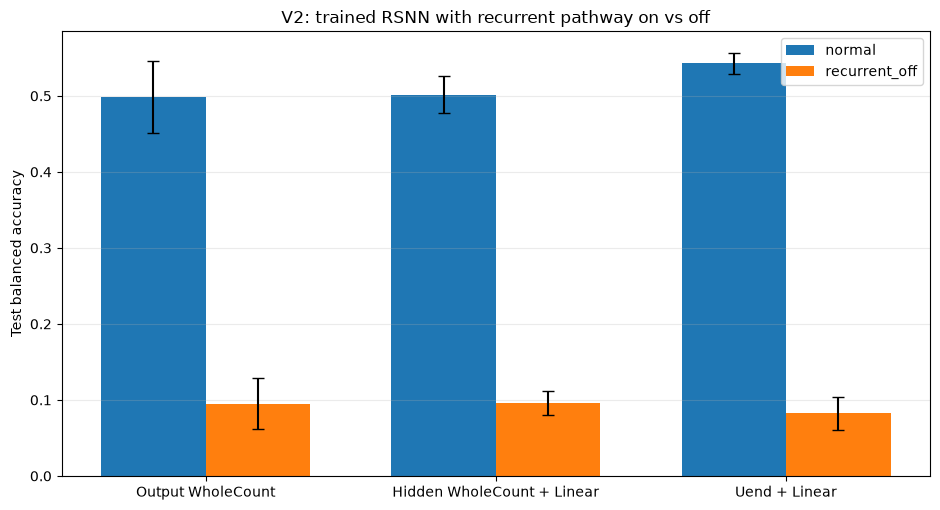

,readout,mean,std,count
0,hidden_whole_count_linear,0.405255,0.039394,5
1,output_whole_count,0.402768,0.076403,5
2,uend_linear,0.460555,0.031626,5


In [4]:
v2_test = classification_runs.query("split == 'test' and model_kind == 'rsnn' and condition in ['normal', 'recurrent_off']").copy()
v2_long = v2_test.melt(
    id_vars=['seed', 'condition'],
    value_vars=list(READOUTS),
    var_name='metric',
    value_name='balanced_accuracy',
)
v2_long['readout'] = v2_long['metric'].map(READOUTS)
v2_summary = (
    v2_long.groupby(['condition', 'readout'])['balanced_accuracy']
    .agg(['mean', 'std', 'count'])
    .reset_index()
)
display(v2_summary)

x = np.arange(len(readout_order), dtype=float)
fig, ax = plt.subplots(figsize=(9.5, 5.2))
for offset, condition in zip((-width / 2, width / 2), ('normal', 'recurrent_off'), strict=True):
    part = v2_summary[v2_summary.condition == condition].set_index('readout').reindex(readout_order)
    ax.bar(x + offset, part['mean'], width, yerr=part['std'], capsize=4, label=condition)
ax.set_xticks(x, readout_order)
ax.set_ylabel('Test balanced accuracy')
ax.set_title('V2: trained RSNN with recurrent pathway on vs off')
ax.legend()
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

v2_effect = paired_effects_summary.query("effect == 'rsnn_normal_minus_recurrent_off'")[[
    'readout', 'mean', 'std', 'count'
]].copy()
display(v2_effect.sort_values('readout').reset_index(drop=True))


## V3 — Periodic Stage-2-only reset

The intervention clears Stage-2 membrane and previous Stage-2 spikes every 250/500/1000 ms while leaving Local128 and the output membrane untouched. The primary plot therefore uses `Uend + Linear`. The y-axis is `NoReset - Reset`; positive values mean destroying Stage-2 history hurts.

,model_kind,readout,reset_ms,mean,std,count
0,ff,hidden_whole_count_linear,250,0.019786,0.022051,5
1,ff,hidden_whole_count_linear,500,0.010145,0.007902,5
2,ff,hidden_whole_count_linear,1000,0.016649,0.019963,5
3,rsnn,hidden_whole_count_linear,250,0.346789,0.040706,5
4,rsnn,hidden_whole_count_linear,500,0.319037,0.040568,5
5,rsnn,hidden_whole_count_linear,1000,0.218979,0.031913,5
6,ff,output_whole_count,250,0.015755,0.018332,5
7,ff,output_whole_count,500,0.000074,0.017414,5
8,ff,output_whole_count,1000,0.000689,0.013754,5
9,rsnn,output_whole_count,250,0.360109,0.071428,5


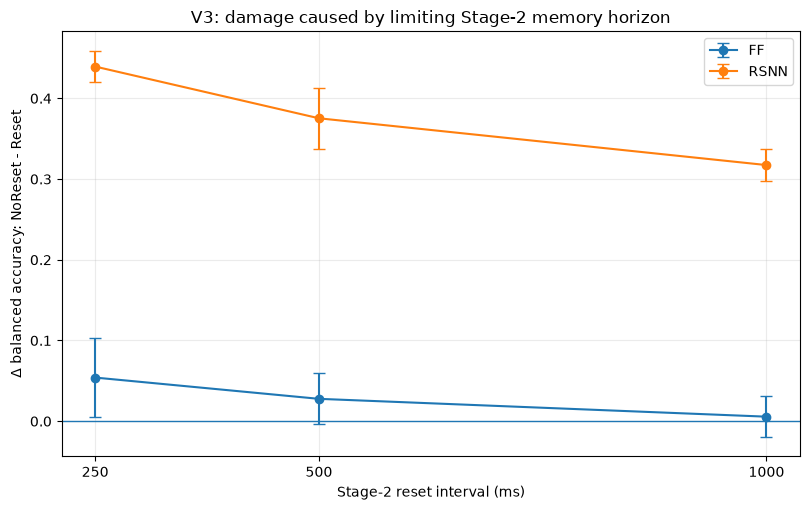

In [5]:
v3 = paired_effects.query("effect == 'normal_minus_periodic_reset'").copy()
v3['reset_ms'] = v3['condition'].str.extract(r'reset_(\d+)ms').astype(int)
v3_summary = (
    v3.groupby(['model_kind', 'readout', 'reset_ms'])['delta_ba']
    .agg(['mean', 'std', 'count'])
    .reset_index()
)
display(v3_summary.sort_values(['readout', 'model_kind', 'reset_ms']).reset_index(drop=True))

uend_v3 = v3_summary[v3_summary.readout == 'uend_linear']
fig, ax = plt.subplots(figsize=(8.2, 5.2))
for model_kind in ('ff', 'rsnn'):
    part = uend_v3[uend_v3.model_kind == model_kind].sort_values('reset_ms')
    ax.errorbar(part['reset_ms'], part['mean'], yerr=part['std'], marker='o', capsize=4, label=model_kind.upper())
ax.axhline(0.0, linewidth=1)
ax.set_xticks(EXPECTED_RESET_MS)
ax.set_xlabel('Stage-2 reset interval (ms)')
ax.set_ylabel('Δ balanced accuracy: NoReset - Reset')
ax.set_title('V3: damage caused by limiting Stage-2 memory horizon')
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


## V4 — Silent-delay retention after each sample's true endpoint

Input is forced to zero after the valid endpoint and the network evolves naturally. The exact delay-0 `Uend` probe is reused at every delay. A slower RSNN decay than FF is evidence that recurrence extends decodable state beyond passive membrane persistence.

,model_kind,delay_ms,uend_linear_ba_mean,uend_linear_ba_std,uend_linear_ba_count,uend_linear_macro_f1_mean,uend_linear_macro_f1_std,uend_linear_macro_f1_count
0,ff,0,0.178183,0.029920,5,0.178012,0.032246,5
1,ff,250,0.123449,0.029492,5,0.076026,0.025584,5
2,ff,500,0.098147,0.023265,5,0.026614,0.019067,5
3,ff,1000,0.083333,0.000000,5,0.012281,0.002187,5
4,ff,2000,0.083333,0.000000,5,0.012244,0.002136,5
5,rsnn,0,0.542980,0.014059,5,0.535623,0.013930,5
6,rsnn,250,0.391490,0.098703,5,0.382649,0.096190,5
7,rsnn,500,0.241415,0.111141,5,0.196742,0.108731,5
8,rsnn,1000,0.102536,0.023722,5,0.044445,0.028457,5
9,rsnn,2000,0.083333,0.000000,5,0.013060,0.002171,5


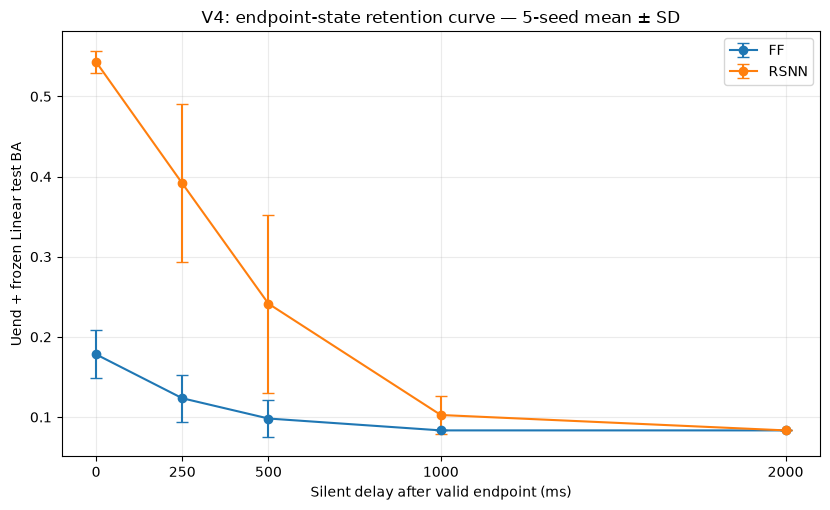

,model_kind,condition,readout,mean,std,count,delay_ms
0,ff,delay_250ms,uend_linear,0.054734,0.026570,5,250
1,ff,delay_500ms,uend_linear,0.080036,0.034716,5,500
2,ff,delay_1000ms,uend_linear,0.094850,0.029920,5,1000
3,ff,delay_2000ms,uend_linear,0.094850,0.029920,5,2000
4,rsnn,delay_250ms,uend_linear,0.151489,0.099538,5,250
5,rsnn,delay_500ms,uend_linear,0.301564,0.111474,5,500
6,rsnn,delay_1000ms,uend_linear,0.440443,0.023484,5,1000
7,rsnn,delay_2000ms,uend_linear,0.459646,0.014059,5,2000


In [6]:
display(retention_summary.sort_values(['model_kind', 'delay_ms']).reset_index(drop=True))

fig, ax = plt.subplots(figsize=(8.4, 5.2))
for model_kind in ('ff', 'rsnn'):
    part = retention_summary[retention_summary.model_kind == model_kind].sort_values('delay_ms')
    ax.errorbar(
        part['delay_ms'],
        part['uend_linear_ba_mean'],
        yerr=part['uend_linear_ba_std'],
        marker='o',
        capsize=4,
        label=model_kind.upper(),
    )
ax.set_xticks(EXPECTED_DELAYS_MS)
ax.set_xlabel('Silent delay after valid endpoint (ms)')
ax.set_ylabel('Uend + frozen Linear test BA')
ax.set_title('V4: endpoint-state retention curve — 5-seed mean ± SD')
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

v4_drop = paired_effects_summary.query("effect == 'silent_delay_drop_from_0ms'")[[
    'model_kind', 'condition', 'readout', 'mean', 'std', 'count'
]].copy()
v4_drop['delay_ms'] = v4_drop['condition'].str.extract(r'delay_(\d+)ms').astype(int)
display(v4_drop.sort_values(['model_kind', 'delay_ms']).reset_index(drop=True))


## Compact mechanism dashboard

This table puts the paired `Uend` effects in one place. It deliberately reports effect direction and seed variability rather than turning the experiment into a significance-testing exercise.

In [7]:
def one_effect(effect: str, *, model_kind: str | None = None, condition: str | None = None) -> pd.Series:
    q = paired_effects_summary[(paired_effects_summary.effect == effect) & (paired_effects_summary.readout == 'uend_linear')].copy()
    if model_kind is not None:
        q = q[q.model_kind.fillna('') == model_kind]
    if condition is not None:
        q = q[q.condition == condition]
    if len(q) != 1:
        raise ValueError(f'Expected exactly one effect row for {effect=} {model_kind=} {condition=}, got {len(q)}')
    return q.iloc[0]

dashboard_rows = []
row = one_effect('rsnn_minus_ff', condition='normal')
dashboard_rows.append({'validation': 'V1', 'comparison': 'RSNN - FF', 'mean_delta_ba': row['mean'], 'sd_delta_ba': row['std'], 'n_pairs': row['count'], 'positive_means': 'RSNN endpoint state is more discriminative'})
row = one_effect('rsnn_normal_minus_recurrent_off', model_kind='rsnn', condition='recurrent_off')
dashboard_rows.append({'validation': 'V2', 'comparison': 'RSNN normal - recurrence_off', 'mean_delta_ba': row['mean'], 'sd_delta_ba': row['std'], 'n_pairs': row['count'], 'positive_means': 'trained RSNN depends on recurrent feedback'})
for model_kind in ('ff', 'rsnn'):
    for reset_ms in EXPECTED_RESET_MS:
        condition = f'reset_{reset_ms}ms'
        row = one_effect('normal_minus_periodic_reset', model_kind=model_kind, condition=condition)
        dashboard_rows.append({'validation': 'V3', 'comparison': f'{model_kind.upper()} NoReset - Reset{reset_ms}', 'mean_delta_ba': row['mean'], 'sd_delta_ba': row['std'], 'n_pairs': row['count'], 'positive_means': 'Stage-2 history beyond that reset interval matters'})
for model_kind in ('ff', 'rsnn'):
    for delay_ms in EXPECTED_DELAYS_MS[1:]:
        condition = f'delay_{delay_ms}ms'
        row = one_effect('silent_delay_drop_from_0ms', model_kind=model_kind, condition=condition)
        dashboard_rows.append({'validation': 'V4', 'comparison': f'{model_kind.upper()} BA(0) - BA({delay_ms}ms)', 'mean_delta_ba': row['mean'], 'sd_delta_ba': row['std'], 'n_pairs': row['count'], 'positive_means': 'endpoint information decays during silence'})

mechanism_dashboard = pd.DataFrame(dashboard_rows)
assert set(mechanism_dashboard['n_pairs'].astype(int)) == {len(EXPECTED_SEEDS)}
display(mechanism_dashboard)


,validation,comparison,mean_delta_ba,sd_delta_ba,n_pairs,positive_means
0,V1,RSNN - FF,0.364796,0.028036,5,RSNN endpoint state is more discriminative
1,V2,RSNN normal - recurrence_off,0.460555,0.031626,5,trained RSNN depends on recurrent feedback
2,V3,FF NoReset - Reset250,0.054061,0.048559,5,Stage-2 history beyond that reset interval mat...
3,V3,FF NoReset - Reset500,0.027725,0.031786,5,Stage-2 history beyond that reset interval mat...
4,V3,FF NoReset - Reset1000,0.005625,0.025401,5,Stage-2 history beyond that reset interval mat...
5,V3,RSNN NoReset - Reset250,0.439397,0.019690,5,Stage-2 history beyond that reset interval mat...
6,V3,RSNN NoReset - Reset500,0.375314,0.037664,5,Stage-2 history beyond that reset interval mat...
7,V3,RSNN NoReset - Reset1000,0.317354,0.020171,5,Stage-2 history beyond that reset interval mat...
8,V4,FF BA(0) - BA(250ms),0.054734,0.026570,5,endpoint information decays during silence
9,V4,FF BA(0) - BA(500ms),0.080036,0.034716,5,endpoint information decays during silence


## Interpretation guardrails

- **Do not use `Uend > OutputWholeCount` as evidence that recurrence caused memory.** It only says the internal endpoint state contains information not fully exposed by the output spike-count readout.
- A recurrence claim should be supported jointly by **V1 (`RSNN - FF`) and V2 (`normal - recurrence_off`)**.
- A long-horizon memory claim should be based primarily on **V3 reset sensitivity and V4 silent-delay retention**, with `Uend` as the primary diagnostic.
- WholeCount remains useful as the end-to-end system metric, but it is secondary for V3 because accumulated spikes can survive a later Stage-2 reset.
- The notebook reports mean ± SD over the five paired seeds; inspect the raw paired tables when a mean effect is driven by only one or two seeds.